# **Radial Metallicity Relations in Simulations**

Code component of Question 3 of ASTR4004 Problem Set 2. See assignment write-up for full answer to Question 3.

**The radial metallicity relation describes the change of metallicity - here, the gas-phase metallicity $A(\mathrm{O}) = \log_{10}(N_\mathrm{O}\,/\,N_\mathrm{H}) + 12$ - which Galactocentric cylindrical radius, $R_\mathrm{Gal}$. Radial metallicity gradients provide insight into processes such as inside-out formation, gas accretion, outflows, and radial migration. A lot of work has been done through observational studies and a few simulations, but more work is needed to understand variations of the radial metallicity gradient.**

**Your colleague has completed a cosmological simulation of a MW-like spiral galaxy. The `.fits` file `data/nihao_uhd_simulation_g8.26` `e11_xyz_positions_and_oxygen_ao.fits` contains the gas-phase metallicity $A(\mathrm{O})$ and $(x,\,y,\,z)$ positions of gas particles within $R_\mathrm{Gal} = \sqrt{x^2 + y^2} < 25\,\mathrm{kpc}$. Perform the following tasks and save your figures in `figures/`.**

## **PART A**

**Plot a two-panel figure: logarithmic density plot of $R_\mathrm{Gal}$ vs $A(\mathrm{O})$, with a linear fit and a legend; residuals of the fit, $R_\mathrm{Gal}$ vs $\Delta A(\mathrm{O})$.**

Import necessary packages.

In [2]:
# packages handling arrays
import numpy as np
import pandas as pd
# package for data visualisation
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm # for log cmaps
# astropy for handling data in .fits format
from astropy.io import fits

Read-in data to a `np.array()`.

In [3]:
# read-in to file (containing header/metadata)
data_file = fits.open("data/q3_simulation_data.fits")
# extract data
data = np.array(data_file[1].data)

Prepare figure axes variables.

In [4]:
x = np.sqrt((data["x"])**2 + (data["y"])**2) # R_Gal (same for both panels)
y_main = data["A_O"] # A(O)
fit_res = np.polyfit(x, y_main, 1) # linear fit (deg=1), returns [m, b]
y_fit = (fit_res[0])*x + fit_res[1] # y = mx + b
y_resid = y_main - y_fit

Create 2-panel figure and save.

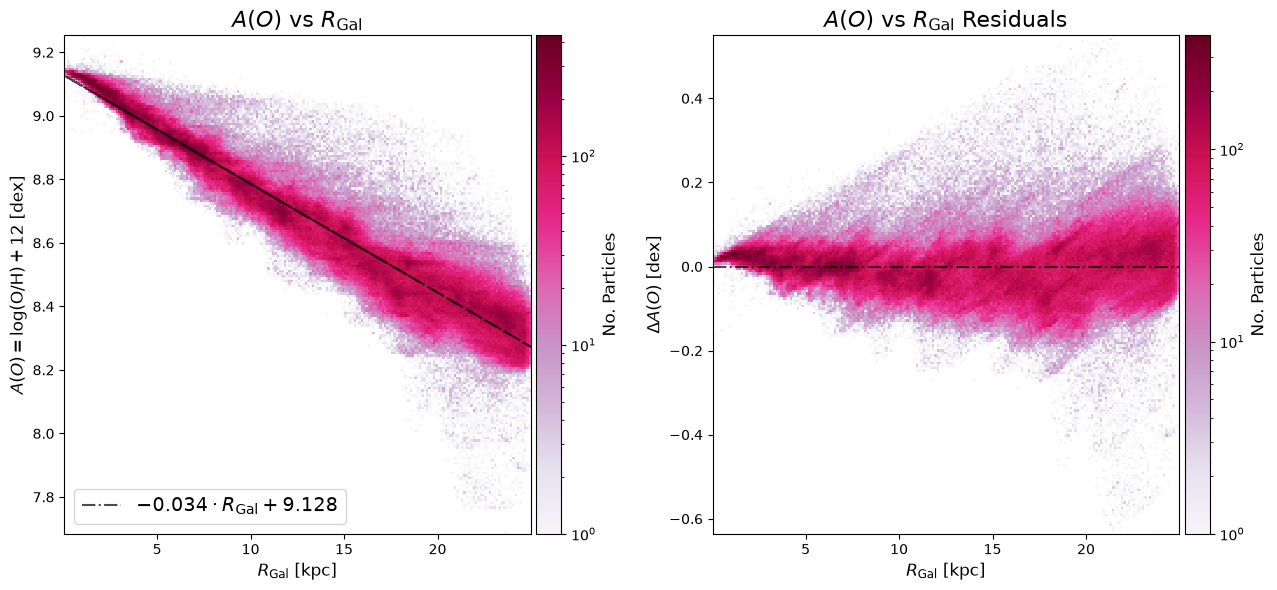

In [24]:
# define figure with two horizontally-stacked subplots
fig, axs = plt.subplots(1, 2, figsize=(13,6), sharex=False, sharey=False)
binsize = 200

# main (left) panel
ax = axs[0]
h_main = ax.hist2d(x, y_main, bins=binsize, cmap="PuRd", norm=LogNorm()) # define 2D hist
ax.plot(x, y_fit, lw=1.5, marker="", c="black", label=rf"${fit_res[0]:.3f}\cdot R_\mathrm{{Gal}} + {fit_res[1]:.3f}$",
        ls="-.", alpha=0.7)
ax.set_title(r"$A(O)$ vs $R_\mathrm{Gal}$", fontsize=16) # panel title
ax.set_ylabel(r"$A(O) = \log(\mathrm{O}/\mathrm{H}) + 12$ [dex]", fontsize=12) # y axis label
ax.set_xlabel(r"$R_\mathrm{Gal}$ [kpc]", fontsize=12) # x label
cbar = fig.colorbar(h_main[3], ax=ax, label="No. Particles", pad=0.01)
cbar.set_label("No. Particles", fontsize=12)
ax.legend(loc="lower left", fontsize=14)

# residuals (right) panel
ax = axs[1]
h_resid = ax.hist2d(x, y_resid, bins=binsize, cmap="PuRd", norm=LogNorm()) # define 2D hist
ax.axhline(0, c="black", lw=1.5, ls="-.", alpha=0.7)
ax.set_title(r"$A(O)$ vs $R_\mathrm{Gal}$ Residuals", fontsize=16)
ax.set_ylabel(r"$\Delta A(O)$ [dex]", fontsize=12)
ax.set_xlabel(r"$R_\mathrm{Gal}$ [kpc]", fontsize=12)
cbar = fig.colorbar(h_resid[3], ax=ax, label="No. Particles", pad=0.01)
cbar.set_label("No. Particles", fontsize=12)

plt.tight_layout() # minimise whitespace around/between panels
plt.savefig("figures/q3a_gasphase.png", dpi=200) # save to figures/
plt.show() # display figure

## **PART B**

**Use a `Python` fitting tool to fit a linear function to the data, reporting the intercept and slope with uncertainties. Include any hyperparameters used.**

## **PART D**

**Plot a three-panel figure for the $x$ vs $y$ plane using the same bins and sensible colormaps: 2D histograms of the median simulated $A(\mathrm{O})$; 2D histogram of the median fitted $A(\mathrm{O})$; 2D histogram of the median residuals $\Delta A(\mathrm{O})$.**